In [50]:
import os
import sys
import glob
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import seaborn as sns

from itertools import chain
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

from playsound import playsound
from scipy.interpolate import interp1d

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [51]:
# product, time_reso = 'IMERG', '1dy'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'CHIRPS', '1dy'
# product, time_reso = 'ERA5', '3h'

# product, time_reso = 'MSWEP', '3h'
product, time_reso = 'GSMaP', '3h'

In [52]:
dir_seeds = os.path.join('..','..','output','RE_bias')
dir_RSR_RE = os.path.join('..','..','output','RE')

In [53]:
RE_RSR = pd.read_csv(os.path.join(dir_RSR_RE,f'RE_{product}.csv'))
RE_RSR.head(3)

,Lon,Lat,Elev,Elev_norm,Mevd_OBS,Mevd_SAT,Mevd_DOWN,RE_SAT,RE_DOWN,ME_SAT,ME_DOWN
0,7.847798,45.514302,338.677490,0.111968,189.421186,88.454119,89.363923,-0.533029,-0.528226,0.466971,0.471774
1,7.390821,44.963696,322.049591,0.106513,163.298540,82.406719,82.603386,-0.495362,-0.494157,0.504638,0.505843
2,7.492737,45.288798,582.489075,0.191947,258.766315,98.834863,98.071320,-0.618054,-0.621004,0.381946,0.378996


In [54]:
seed_files = glob.glob(os.path.join(dir_seeds,f'RE_{product}*.csv'))
seed_files = sorted(seed_files)
seed_len = len(seed_files)
print(f'Files number: {seed_len}')

Files number: 100


In [55]:
RE_seeds = None
for nn in range(seed_len):
    RE_data = pd.read_csv(seed_files[nn])
    if RE_seeds is None:
        RE_seeds = np.zeros([len(RE_data),seed_len])*np.nan
    RE_seeds[:,nn] = np.array(RE_data['RE_SAT'].values)

Export as: ../../figures/RE/compare/GSMaP_RE_SAT_DOWN_BIAS.png


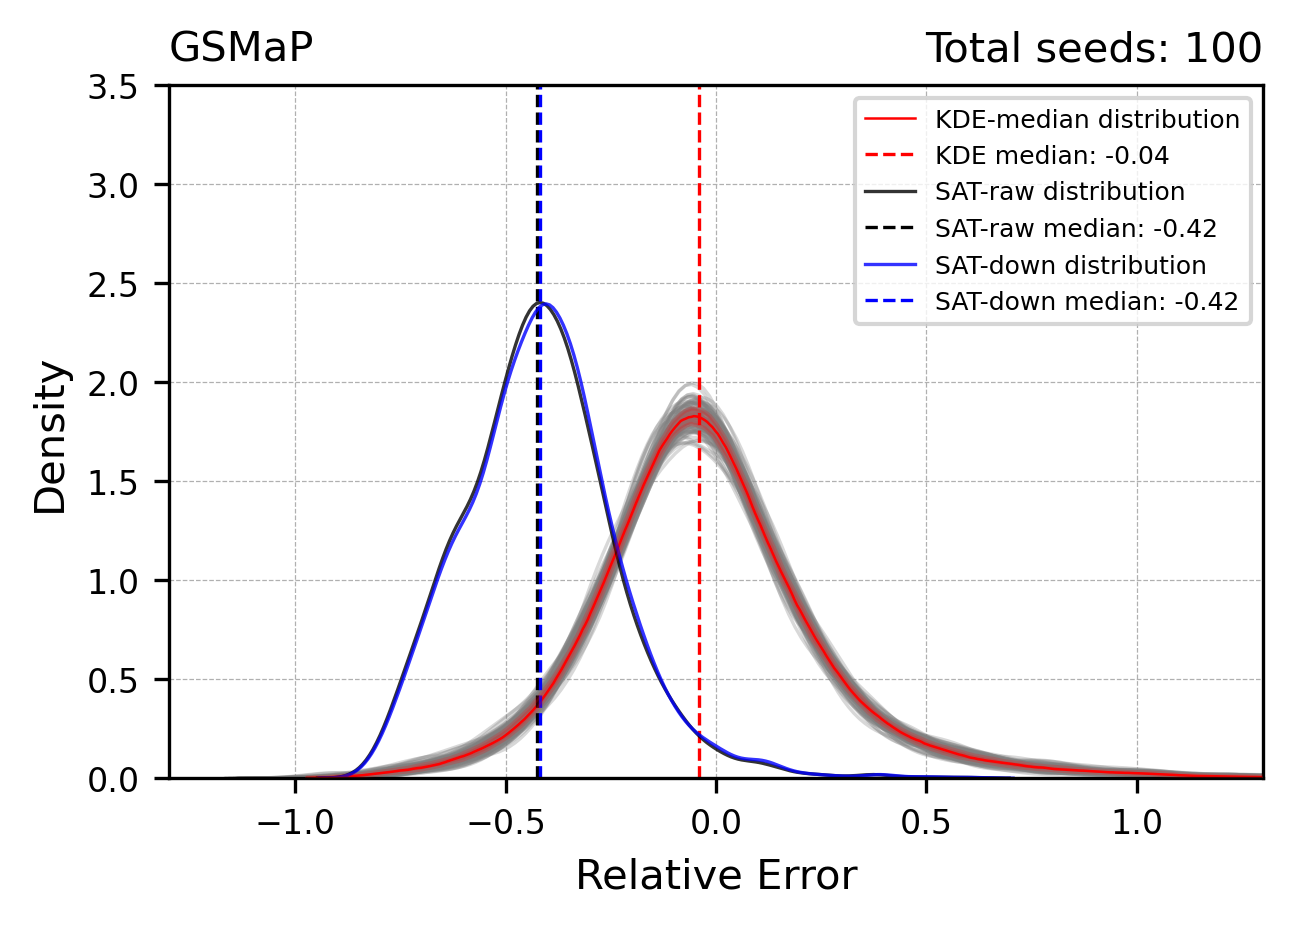

In [56]:
fig = plt.figure(figsize=(16,3),dpi=300)
gs = gridspec.GridSpec(1,3)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 0])

for nn in range(RE_seeds.shape[1]):
    sns.kdeplot(RE_seeds[:, nn], color='gray', alpha=0.3, linewidth=0.8, ax=ax1)

x_grid = np.linspace(np.nanmin(RE_seeds), np.nanmax(RE_seeds), 500)

kde_values = np.zeros((len(x_grid), RE_seeds.shape[1]))

for nn in range(RE_seeds.shape[1]):
    data = RE_seeds[:, nn][~np.isnan(RE_seeds[:, nn])]
    if len(data) > 1:
        kde = gaussian_kde(data)
        kde_values[:, nn] = kde(x_grid)

median_kde = np.nanmedian(kde_values, axis=1)
p25_kde = np.nanpercentile(kde_values, 25, axis=1)
p75_kde = np.nanpercentile(kde_values, 75, axis=1)

ax1.plot(x_grid, median_kde, color='red', linewidth=0.6, label='KDE-median distribution')
ax1.axvline(x=np.nanmedian(RE_seeds,axis=[0,1]), color='red', linestyle='--', linewidth=0.8, label=f'KDE median: {np.round(np.nanmedian(RE_seeds,axis=[0,1]),2)}')
ax1.fill_between(x_grid, p25_kde, p75_kde, alpha=0.2, color='red',zorder=40)

sns.kdeplot(RE_RSR['RE_SAT'], color='k', alpha=0.8, linewidth=0.8, ax=ax1, label='SAT-raw distribution')
ax1.axvline(x=np.nanmedian(RE_RSR['RE_SAT'].values), color='k', linestyle='--', linewidth=0.8, label=f'SAT-raw median: {np.round(np.nanmedian(RE_RSR['RE_SAT'].values),2)}')
sns.kdeplot(RE_RSR['RE_DOWN'], color='b', alpha=0.8, linewidth=0.8, ax=ax1, label='SAT-down distribution')
ax1.axvline(x=np.nanmedian(RE_RSR['RE_DOWN'].values), color='b', linestyle='--', linewidth=0.8, label=f'SAT-down median: {np.round(np.nanmedian(RE_RSR['RE_DOWN'].values),2)}')

ax1.set_xlabel('Relative Error')
ax1.set_ylabel('Density')
ax1.set_title(f'{product}',loc='left',fontsize=10)
ax1.set_title(f'Total seeds: {seed_len}',loc='right',fontsize=10)
ax1.legend(fontsize=6,loc=1)
ax1.set_xlim(-1.3,1.3)
ax1.set_ylim(0,3.5)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=8)

dir_out = os.path.join('..','..','figures','RE','compare',f'{product}_RE_SAT_DOWN_BIAS.png')
print(F'Export as: {dir_out}')
plt.savefig(dir_out,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)